###  End-to-End Speech Recognition Training Framework

Title:
Custom CTC-Based Speech Recognition System

Short Description:
This code implements a complete pipeline for training a custom speech recognition model using Connectionist Temporal Classification (CTC). It handles dataset preparation, feature extraction, model architecture, and training loop for converting speech to text using LibriSpeech audio files and transcripts.

Key Libraries Used:

    torch/torchaudio: Audio processing and deep learning framework

    string: Character mapping utilities

    os: File system operations

Code Logic and Flow

High-Level Overview:
The framework processes LibriSpeech audio-transcript pairs through five stages: dataset loading with transcript matching, audio preprocessing to mel-spectrograms, batch collation with padding, CTC-based model training, and periodic model checkpointing. It implements a convolutional-LSTM architecture optimized for sequence-to-text conversion.

Visual FlowChart:

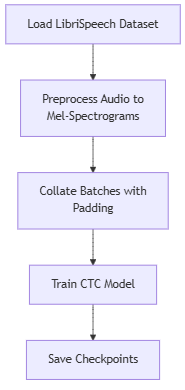

Step-by-Step Code Breakdown

Step 1: Custom Dataset Handling

    Scans directory for .flac files and matching .trans/.trans.txt

    Creates mapping between utterance IDs and transcripts

    Handles case normalization and file loading errors

    Returns waveform, sample rate, transcript, and file path

Step 2: Character Mapping

    Defines alphabet: lowercase letters + space/apostrophe

    Creates char-to-index mapping with blank (0) for CTC

    Supports 28-character vocabulary

Step 3: Audio Preprocessing

    Converts stereo to mono by channel averaging

    Resamples to 16kHz if needed

    Computes 128-band mel-spectrograms

    Pads sequences to maximum length in batch

Step 4: Model Architecture

    Frontend: 2D convolution (5x5 kernel) for feature extraction

    Encoder: 2-layer LSTM with 64 hidden units

    Head: Linear layer to character probabilities

    Handles variable-length input sequences

    Outputs logits for CTC loss calculation

Step 5: Training Loop

    Uses Adam optimizer with 1e-4 learning rate

    Computes CTC loss between predictions and transcripts

    Handles variable-length sequences via input/target lengths

    Saves model checkpoint after each epoch

    Implements error handling for batch processing failures

Connecting to the Lecture**

    End-to-End Training: Demonstrates complete ASR pipeline from raw audio to text

    CTC Loss: Implements Connectionist Temporal Classification for alignment-free training

    Feature Engineering: Uses mel-spectrograms as acoustic features

    Sequence Modeling: Combines CNNs for local patterns with LSTMs for temporal dependencies

    Data Handling: Solves real-world challenges in audio-transcript alignment

    Batch Processing: Implements dynamic padding for efficient training

    Model Checkpointing: Ensures training progress preservation

    Error Resilience: Includes exception handling for corrupted data

    Resource Optimization: Runs on CPU for accessibility

    Vocab Design: Shows compact character-based approach for English

In [16]:
import os
import torch
import torchaudio
from torch import nn
from torch.utils.data import Dataset, DataLoader
import string

# 1. Custom Dataset for LibriSpeech folder with .trans or .trans.txt file
class MyLibriSpeechDataset(Dataset):
    def __init__(self, root):
        self.samples = []
        self.transcripts = {}
        print("Files in root directory:")
        for fname in os.listdir(root):
            print(fname)
        # Parse .trans or .trans.txt file in the root directory
        for fname in os.listdir(root):
            if fname.endswith('.trans') or fname.endswith('.trans.txt'):
                trans_path = os.path.join(root, fname)
                print(f"Parsing transcript file: {trans_path}")
                with open(trans_path, 'r', encoding='utf-8') as f:
                    for line in f:
                        parts = line.strip().split(' ', 1)
                        if len(parts) == 2:
                            utt_id, text = parts
                            utt_id = utt_id.strip().lower()
                            self.transcripts[utt_id] = text
        print("Transcript keys:", list(self.transcripts.keys()))
        # Find all .flac files and match with transcript
        for fname in os.listdir(root):
            if fname.endswith('.flac'):
                utt_id = os.path.splitext(fname)[0].strip().lower()
                print(f"Found audio: {fname}, utt_id: {utt_id}")
                audio_path = os.path.join(root, fname)
                if utt_id in self.transcripts:
                    self.samples.append((audio_path, self.transcripts[utt_id]))
                else:
                    print(f"Transcript not found for: {audio_path}")
        print(f"Total samples found: {len(self.samples)}")

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        audio_path, transcript = self.samples[idx]
        try:
            waveform, sr = torchaudio.load(audio_path)
        except Exception as e:
            print(f"Error loading audio {audio_path}: {e}")
            raise
        return waveform, sr, transcript, audio_path

# 2. Char-to-Index Mapping
alphabet = string.ascii_lowercase + " '"
char_to_idx = {c: i+1 for i, c in enumerate(alphabet)}  # 0 is reserved for CTC blank

# 3. Custom collate function for padding
n_mels = 128
def collate_fn(batch):
    waveforms, srs, transcripts, audio_paths = zip(*batch)
    # Resample and mono
    waveforms = [w.mean(dim=0, keepdim=True) if w.dim() > 1 else w for w in waveforms]
    waveforms = [w if s == 16000 else torchaudio.transforms.Resample(s, 16000)(w) for w, s in zip(waveforms, srs)]
    # MelSpectrogram
    mels = [torchaudio.transforms.MelSpectrogram(n_mels=n_mels)(wav) for wav in waveforms]
    # Pad to max time length
    max_len = max(mel.shape[-1] for mel in mels)
    mels_padded = []
    for mel in mels:
        pad_width = max_len - mel.shape[-1]
        if pad_width > 0:
            mel = torch.nn.functional.pad(mel, (0, pad_width))
        mels_padded.append(mel)
    mels_padded = torch.stack(mels_padded)  # (batch, n_mels, time)
    return mels_padded, transcripts

# 4. DataLoader
DATA_DIR = r"7.2 End-to-End Training\LibriSpeech\dev-clean\84\121123" #Replace with your filepath
train_data = MyLibriSpeechDataset(DATA_DIR)
print(f"Number of samples in dataset: {len(train_data)}")
train_loader = DataLoader(train_data, batch_size=2, collate_fn=collate_fn, num_workers=0)

# 5. Define Model (Conv2d + LSTM)
class Speech2Text(nn.Module):
    def __init__(self, n_mels, n_chars):
        super().__init__()
        self.frontend = nn.Sequential(
            nn.Conv2d(1, 16, kernel_size=(5, 5), stride=(1, 2)),  # (batch, 16, n_mels-4, time//2)
            nn.ReLU()
        )
        self.n_mels_out = n_mels - 4  # after kernel_size=5 in freq dim
        self.encoder = nn.LSTM(
            input_size=16 * self.n_mels_out,
            hidden_size=64,
            num_layers=2,
            batch_first=True
        )
        self.head = nn.Linear(64, n_chars + 1)  # +1 for CTC blank

    def forward(self, x):
        # x: (batch, 1, n_mels, time)
        x = self.frontend(x)  # (batch, 16, n_mels_out, time_out)
        b, c, f, t = x.shape
        x = x.permute(0, 3, 1, 2).contiguous().view(b, t, c * f)  # (batch, time_out, features)
        x, _ = self.encoder(x)
        return self.head(x)

# 6. Initialize Components
device = torch.device("cpu")
model = Speech2Text(n_mels=n_mels, n_chars=len(char_to_idx)).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)
ctc_loss = nn.CTCLoss(blank=0, zero_infinity=True)

# 7. Training Loop (with model saving)
for epoch in range(5):
    print(f"Starting epoch {epoch}")
    for i, (mels, transcripts) in enumerate(train_loader):
        try:
            mels = mels.to(device)  # (batch, channels, n_mels, time)
            tokens = [torch.tensor([char_to_idx.get(c, 0) for c in text.lower()]) for text in transcripts]
            logits = model(mels)
            log_probs = torch.log_softmax(logits, dim=-1)
            input_lengths = torch.tensor([logits.size(1)] * len(tokens)).to(device)
            target_lengths = torch.tensor([len(t) for t in tokens]).to(device)
            loss = ctc_loss(
                log_probs.permute(1, 0, 2),
                torch.cat(tokens).to(device),
                input_lengths,
                target_lengths
            )
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            print(f"    Epoch {epoch} | Batch {i} | Loss: {loss.item():.4f}")
        except Exception as e:
            print(f"    Error in epoch {epoch}, batch {i}: {e}")
            continue
    # Save model after each epoch
    model_path = os.path.join(r"7.2 End-to-End Training\trained_model", f"model_epoch_{epoch}.pt")  # Replace with your filepath
    torch.save(model.state_dict(), model_path)
    print(f"    Saved model to {model_path}")

Files in root directory:
84-121123-0000.flac
84-121123-0001.flac
84-121123-0002.flac
84-121123-0003.flac
84-121123-0004.flac
84-121123-0005.flac
84-121123-0006.flac
84-121123-0007.flac
84-121123-0008.flac
84-121123-0009.flac
84-121123-0010.flac
84-121123-0011.flac
84-121123-0012.flac
84-121123-0013.flac
84-121123-0014.flac
84-121123-0015.flac
84-121123-0016.flac
84-121123-0017.flac
84-121123-0018.flac
84-121123-0019.flac
84-121123-0020.flac
84-121123-0021.flac
84-121123-0022.flac
84-121123-0023.flac
84-121123-0024.flac
84-121123-0025.flac
84-121123-0026.flac
84-121123-0027.flac
84-121123-0028.flac
84-121123.trans.txt
model_epoch_0.pt
model_epoch_1.pt
model_epoch_2.pt
model_epoch_3.pt
model_epoch_4.pt
Parsing transcript file: C:\Users\vinit_hqjv9wt\Desktop\FinFree Project\Courses\Deep learning for Speech language model\7 Challenges and Future Directions in SpeechLM Research\7.2 End-to-End Training\LibriSpeech\dev-clean\84\121123\84-121123.trans.txt
Transcript keys: ['84-121123-0000', '8